<a href="https://colab.research.google.com/github/Laplace-Feitidote/Machine-Learning-Final-Project/blob/main/Machine_Learning_Final_Project_Slytherin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Cell 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# ถ้าใน Colab ยังไม่มี plotly ให้รัน:
# !pip -q install plotly
import plotly.express as px

✅ Cell 2 — Load datasets

In [ ]:
BREWERIES_PATH = "breweries.csv"
BEERS_PATH     = "beers.csv"

breweries = pd.read_csv(BREWERIES_PATH)
beers     = pd.read_csv(BEERS_PATH)

print("breweries:", breweries.shape)
print("beers:", beers.shape)

display(breweries.head())
display(beers.head())

breweries: (558, 4)
beers: (2410, 8)


,Unnamed: 0,name,city,state
0,0,NorthGate Brewing,Minneapolis,MN
1,1,Against the Grain Brewery,Louisville,KY
2,2,Jack's Abby Craft Lagers,Framingham,MA
3,3,Mike Hess Brewing Company,San Diego,CA
4,4,Fort Point Beer Company,San Francisco,CA


,Unnamed: 0,abv,ibu,id,name,style,brewery_id,ounces
0,0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


✅ Cell 3 — Check columns

In [ ]:
print("Breweries columns:", list(breweries.columns))
print("Beers columns:", list(beers.columns))

Breweries columns: ['Unnamed: 0', 'name', 'city', 'state']
Beers columns: ['Unnamed: 0', 'abv', 'ibu', 'id', 'name', 'style', 'brewery_id', 'ounces']


✅ Cell 4 — Clean basic (drop Unnamed)

In [ ]:
for df_name, df in [("breweries", breweries), ("beers", beers)]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)
        print(f"Dropped Unnamed: 0 from {df_name}")

Dropped Unnamed: 0 from breweries
Dropped Unnamed: 0 from beers


✅ Cell 5 — Clean state codes

In [ ]:
breweries["state"] = breweries["state"].astype(str).str.strip().str.upper()
breweries = breweries[breweries["state"].str.len() == 2].copy()

print("Unique states:", breweries["state"].nunique())
print("Top states sample:")
display(breweries["state"].value_counts().head(10))

Unique states: 51
Top states sample:


,count
state,
CO,47
CA,39
MI,32
OR,29
TX,28
PA,25
MA,23
WA,23
IN,22


✅ Cell 6 — Count breweries by state

In [ ]:
brewery_by_state = (
    breweries.groupby("state")
    .size()
    .reset_index(name="brewery_count")
    .sort_values("brewery_count", ascending=False)
)

display(brewery_by_state.head(15))

,state,brewery_count
5,CO,47
4,CA,39
22,MI,32
37,OR,29
43,TX,28
38,PA,25
47,WA,23
19,MA,23
15,IN,22
48,WI,20


✅ Cell 7 — Bar chart Top 10 states

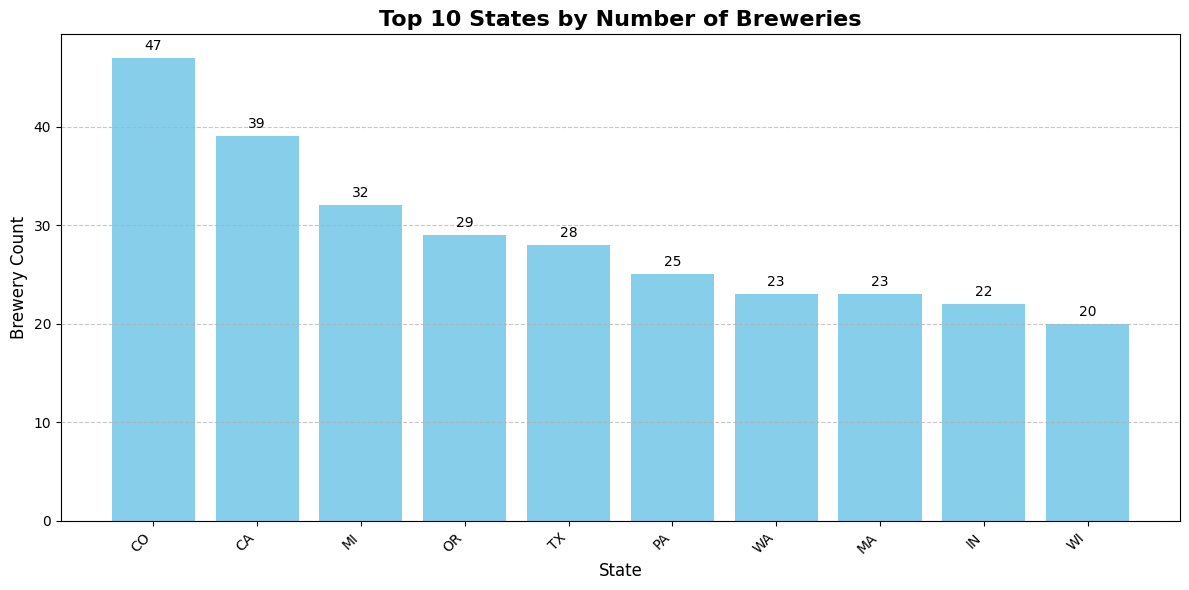

In [ ]:
top10 = brewery_by_state.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10["state"], top10["brewery_count"], color='skyblue')
plt.title("Top 10 States by Number of Breweries", fontsize=16, fontweight='bold')
plt.xlabel("State", fontsize=12)
plt.ylabel("Brewery Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels
for index, value in enumerate(top10["brewery_count"]):
    plt.text(index, value + 0.5, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

✅ Cell 8 — Choropleth map: Breweries count by state

In [ ]:
fig = px.choropleth(
    brewery_by_state,
    locations="state",
    locationmode="USA-states",
    color="brewery_count",
    scope="usa",
    hover_name="state",
    hover_data={"brewery_count": True, "state": False},
    title="Brewery Distribution by State (Count)",
    color_continuous_scale="Plasma" # Choose a more vibrant color scale
)
fig.update_layout(
    title_font_size=20,
    title_x=0.5, # Center the title
    coloraxis_colorbar_title_text="Number of Breweries"
)
fig.show()

✅ Cell 9 — Create brewery_id for merge + merge beers with state

In [ ]:
breweries_merged = breweries.reset_index().rename(columns={"index": "brewery_id"})

df = beers.merge(
    breweries_merged[["brewery_id", "state"]],
    on="brewery_id",
    how="left"
)

df["state"] = df["state"].astype(str).str.strip().str.upper()
df = df[df["state"].str.len() == 2].copy()

print(df.shape)
display(df.head())

(2410, 8)


,abv,ibu,id,name,style,brewery_id,ounces,state
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0,OR
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0,IN
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0,IN
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0,IN
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0,IN


✅ Cell 10 — Beer variety per state (unique beers)

In [ ]:
beer_variety_state = (
    df.groupby("state")["id"]
    .nunique()
    .reset_index(name="unique_beers")
    .sort_values("unique_beers", ascending=False)
)

display(beer_variety_state.head(15))

,state,unique_beers
5,CO,265
4,CA,183
22,MI,162
15,IN,139
43,TX,130
37,OR,125
38,PA,100
14,IL,91
48,WI,87
19,MA,82


✅ Cell 11 — Choropleth map: beer variety

In [ ]:
fig2 = px.choropleth(
    beer_variety_state,
    locations="state",
    locationmode="USA-states",
    color="unique_beers",
    scope="usa",
    hover_name="state",
    hover_data={"unique_beers": True, "state": False},
    title="Beer Variety by State (Unique Beers)",
    color_continuous_scale="Viridis" # Another appealing color scale
)
fig2.update_layout(
    title_font_size=20,
    title_x=0.5,
    coloraxis_colorbar_title_text="Number of Unique Beers"
)
fig2.show()

✅ Cell 12 — Avg ABV / Avg IBU per state

In [ ]:
df["abv"] = pd.to_numeric(df["abv"], errors="coerce")
df["ibu"] = pd.to_numeric(df["ibu"], errors="coerce")

abv_state = (
    df.groupby("state")["abv"]
    .mean()
    .reset_index(name="avg_abv")
    .sort_values("avg_abv", ascending=False)
)

ibu_state = (
    df.groupby("state")["ibu"]
    .mean()
    .reset_index(name="avg_ibu")
    .sort_values("avg_ibu", ascending=False)
)

display(abv_state.head(15))
display(ibu_state.head(15))

,state,avg_abv
33,NV,0.066900
7,DC,0.065625
17,KY,0.064600
15,IN,0.063394
22,MI,0.063377
5,CO,0.063372
14,IL,0.062022
49,WV,0.062000
1,AL,0.062000
35,OH,0.061959


,state,avg_ibu
49,WV,57.500000
32,NM,57.000000
7,DC,55.250000
13,ID,55.117647
21,ME,52.857143
8,DE,52.000000
1,AL,51.222222
23,MN,49.956522
30,NH,48.500000
37,OR,47.942529


✅ Cell 13 — Choropleth map: Avg ABV

In [ ]:
fig3 = px.choropleth(
    abv_state,
    locations="state",
    locationmode="USA-states",
    color="avg_abv",
    scope="usa",
    hover_name="state",
    hover_data={"avg_abv": ":.3f", "state": False},
    title="Average ABV by State",
    color_continuous_scale="Blues" # Sequential scale for ABV
)
fig3.update_layout(
    title_font_size=20,
    title_x=0.5,
    coloraxis_colorbar_title_text="Average ABV"
)
fig3.show()

✅ Cell 14 — Choropleth map: Avg IBU

In [ ]:
fig4 = px.choropleth(
    ibu_state,
    locations="state",
    locationmode="USA-states",
    color="avg_ibu",
    scope="usa",
    hover_name="state",
    hover_data={"avg_ibu": ":.1f", "state": False},
    title="Average IBU by State (Missing IBU may affect results)",
    color_continuous_scale="Greens" # Sequential scale for IBU
)
fig4.update_layout(
    title_font_size=20,
    title_x=0.5,
    coloraxis_colorbar_title_text="Average IBU"
)
fig4.show()

In [ ]:
import pandas as pd

beers_df = pd.read_csv("beers.csv")
breweries_df = pd.read_csv("breweries.csv")

print("Beers Info:")
print(beers_df.info())
print("\nBeers Head:")
print(beers_df.head())

print("\nBreweries Info:")
print(breweries_df.info())
print("\nBreweries Head:")
print(breweries_df.head())

Beers Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2410 non-null   int64  
 1   abv         2348 non-null   float64
 2   ibu         1405 non-null   float64
 3   id          2410 non-null   int64  
 4   name        2410 non-null   object 
 5   style       2405 non-null   object 
 6   brewery_id  2410 non-null   int64  
 7   ounces      2410 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 150.8+ KB
None

Beers Head:
   Unnamed: 0    abv  ibu    id                 name  \
0           0  0.050  NaN  1436             Pub Beer   
1           1  0.066  NaN  2265          Devil's Cup   
2           2  0.071  NaN  2264  Rise of the Phoenix   
3           3  0.090  NaN  2263             Sinister   
4           4  0.075  NaN  2262        Sex and Candy   

                            style  brewery_id  ounces

Text(0, 0.5, 'International Bitterness Units (IBU)')

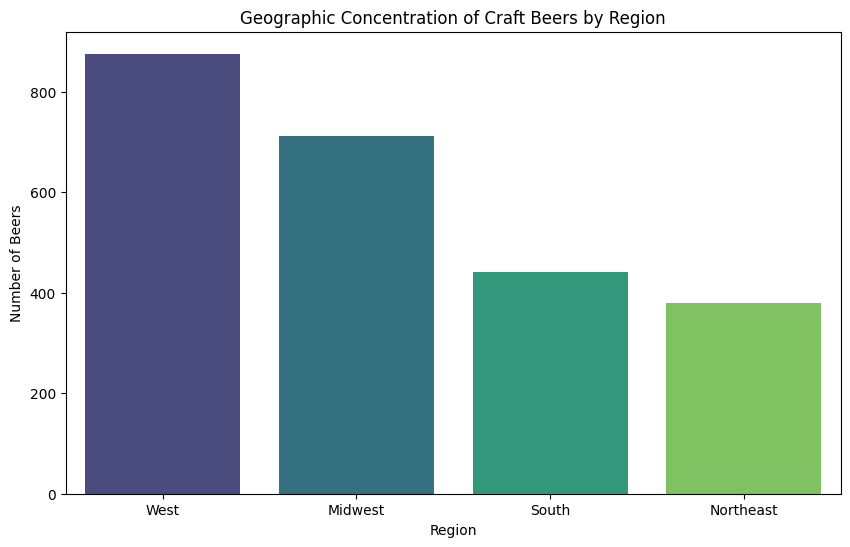

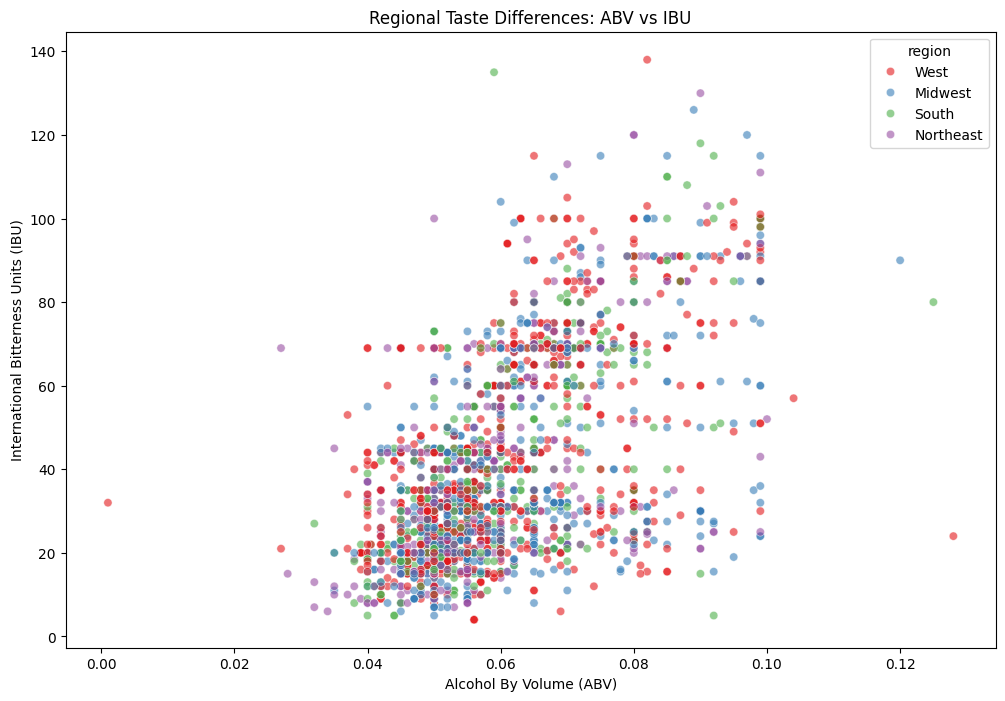

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
beers = pd.read_csv("beers.csv")
breweries = pd.read_csv("breweries.csv")

# Merge datasets
# rename columns for clarity before merging
breweries = breweries.rename(columns={"Unnamed: 0": "brewery_id", "name": "brewery_name"})
beers = beers.rename(columns={"Unnamed: 0": "beer_index", "name": "beer_name"})

df = pd.merge(beers, breweries, on="brewery_id")
df['state'] = df['state'].str.strip() # Remove leading/trailing whitespaces from states

# Define US Regions
regions = {
    'Northeast': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'],
    'Midwest': ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'],
    'South': ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'DC', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX'],
    'West': ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']
}

# Reverse dictionary to map state to region
state_to_region = {state: region for region, states in regions.items() for state in states}
df['region'] = df['state'].map(state_to_region)

# Handle Missing Values for ABV and IBU
# Impute with median of the respective style
df['abv'] = df.groupby('style')['abv'].transform(lambda x: x.fillna(x.median()))
df['ibu'] = df.groupby('style')['ibu'].transform(lambda x: x.fillna(x.median()))

# Fill any remaining NaNs with overall median
df['abv'] = df['abv'].fillna(df['abv'].median())
df['ibu'] = df['ibu'].fillna(df['ibu'].median())

# Save preprocessed data
df.to_csv("cleaned_beer_data.csv", index=False)

# EDA 1: Geographic Concentration
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='region', order=df['region'].value_counts().index, hue='region',palette='viridis')
plt.title("Geographic Concentration of Craft Beers by Region")
plt.ylabel("Number of Beers")
plt.xlabel("Region")

# EDA 2: Regional Taste Differences (ABV vs IBU)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='abv', y='ibu', hue='region', alpha=0.6, palette='Set1')
plt.title("Regional Taste Differences: ABV vs IBU")
plt.xlabel("Alcohol By Volume (ABV)")
plt.ylabel("International Bitterness Units (IBU)")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load data
df = pd.read_csv("cleaned_beer_data.csv")
df = df.dropna(subset=['region'])

# Fill missing values for text fields
df['style'] = df['style'].fillna('Unknown')
df['beer_name'] = df['beer_name'].fillna('')
df['brewery_name'] = df['brewery_name'].fillna('')

# 2. Define Features (Now including Text!) and Target
X = df[['abv', 'ibu', 'style', 'beer_name', 'brewery_name']]
y = df['region']

# 3. Upgraded Preprocessor with NLP
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['abv', 'ibu']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['style']),
        # Extract the top 500 most important words from beer and brewery names
        ('text_beer', TfidfVectorizer(max_features=500, stop_words='english'), 'beer_name'),
        ('text_brewery', TfidfVectorizer(max_features=500, stop_words='english'), 'brewery_name')
    ])

# 4. Define the model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300,
                                          random_state=42,
                                          class_weight='balanced',
                                          max_depth=30)) # Added max_depth to prevent overfitting text
])

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train & Predict
print("Training upgraded NLP model...")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 7. Evaluate
print(f"\nUpgraded Model Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Training upgraded NLP model...

Upgraded Model Accuracy: 0.7469

Classification Report:
              precision    recall  f1-score   support

     Midwest       0.72      0.66      0.69       141
   Northeast       0.91      0.68      0.78        78
       South       0.69      0.76      0.72        84
        West       0.75      0.84      0.79       179

    accuracy                           0.75       482
   macro avg       0.77      0.73      0.74       482
weighted avg       0.75      0.75      0.75       482

